# Decision Tree (XAI Analysis)


**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

**Model:** Decision Tree  

**Task:** Predict Pokémon primary type from sprite color features (17 classes, 42 features)

In [2]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
import shap
import lime
import lime.lime_tabular
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

warnings.filterwarnings("ignore")

cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import common
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

/home/oscar/Work/mlx/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Dataset Load and Preparation

In [3]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

X_train, X_test, y_train, y_test, split_idx = common.get_train_test_split(df)
scaler = common.get_scaler(X_train)
# DTree doesn't need scaling, but we scale for consistency with other notebooks
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=feature_cols, index=X_test.index)

class_weights = common.get_class_weights(y_train)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Classes: {y_train.nunique()}")
print(f"\nClass distribution (train):")
print(y_train.map(int_to_type).value_counts().to_string())

Train size: 820 | Test size: 205
Classes: 17

Class distribution (train):
type1_encoded
water       108
normal       97
grass        82
bug          66
fire         53
psychic      48
electric     47
rock         46
dark         37
poison       34
fighting     33
ground       32
dragon       31
steel        30
ghost        28
ice          25
fairy        23


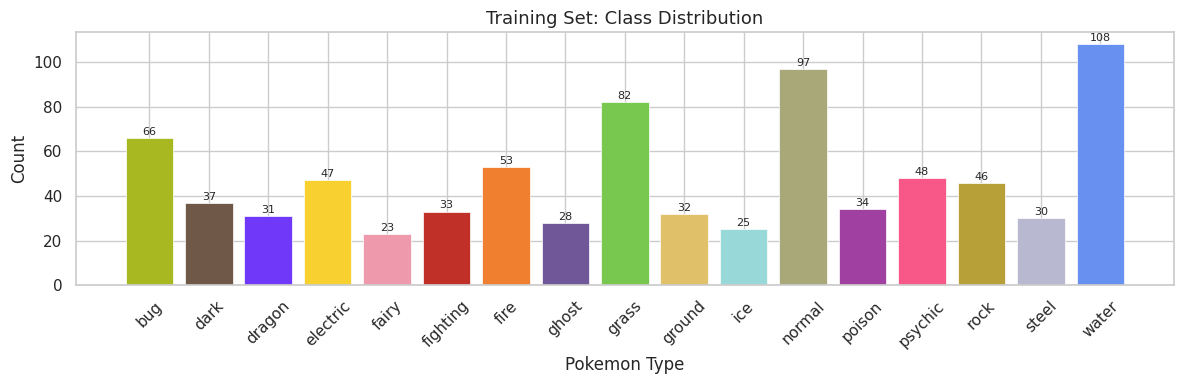

In [4]:
# Bar chart of training class distribution
dist = y_train.map(int_to_type).value_counts().sort_index()
colors = [common.TYPE_COLORS.get(t, "#888888") for t in dist.index]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(dist.index, dist.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_title("Training Set: Class Distribution", fontsize=13)
ax.set_xlabel("Pokemon Type")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=45)
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(val), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# 2. ML Model Training

In [5]:
cv = common.get_cv_splitter(n_splits=5)
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "max_features": [None, "sqrt", "log2"],
}
base_dt = DecisionTreeClassifier(class_weight="balanced", random_state=common.RANDOM_STATE)
grid_search = GridSearchCV(base_dt, param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV f1_macro: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best params: {'criterion': 'gini', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best CV f1_macro: 0.1632


In [6]:
dt = grid_search.best_estimator_
y_pred = dt.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, f1_score
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test f1_macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

Test accuracy: 0.1512
Test f1_macro: 0.1226


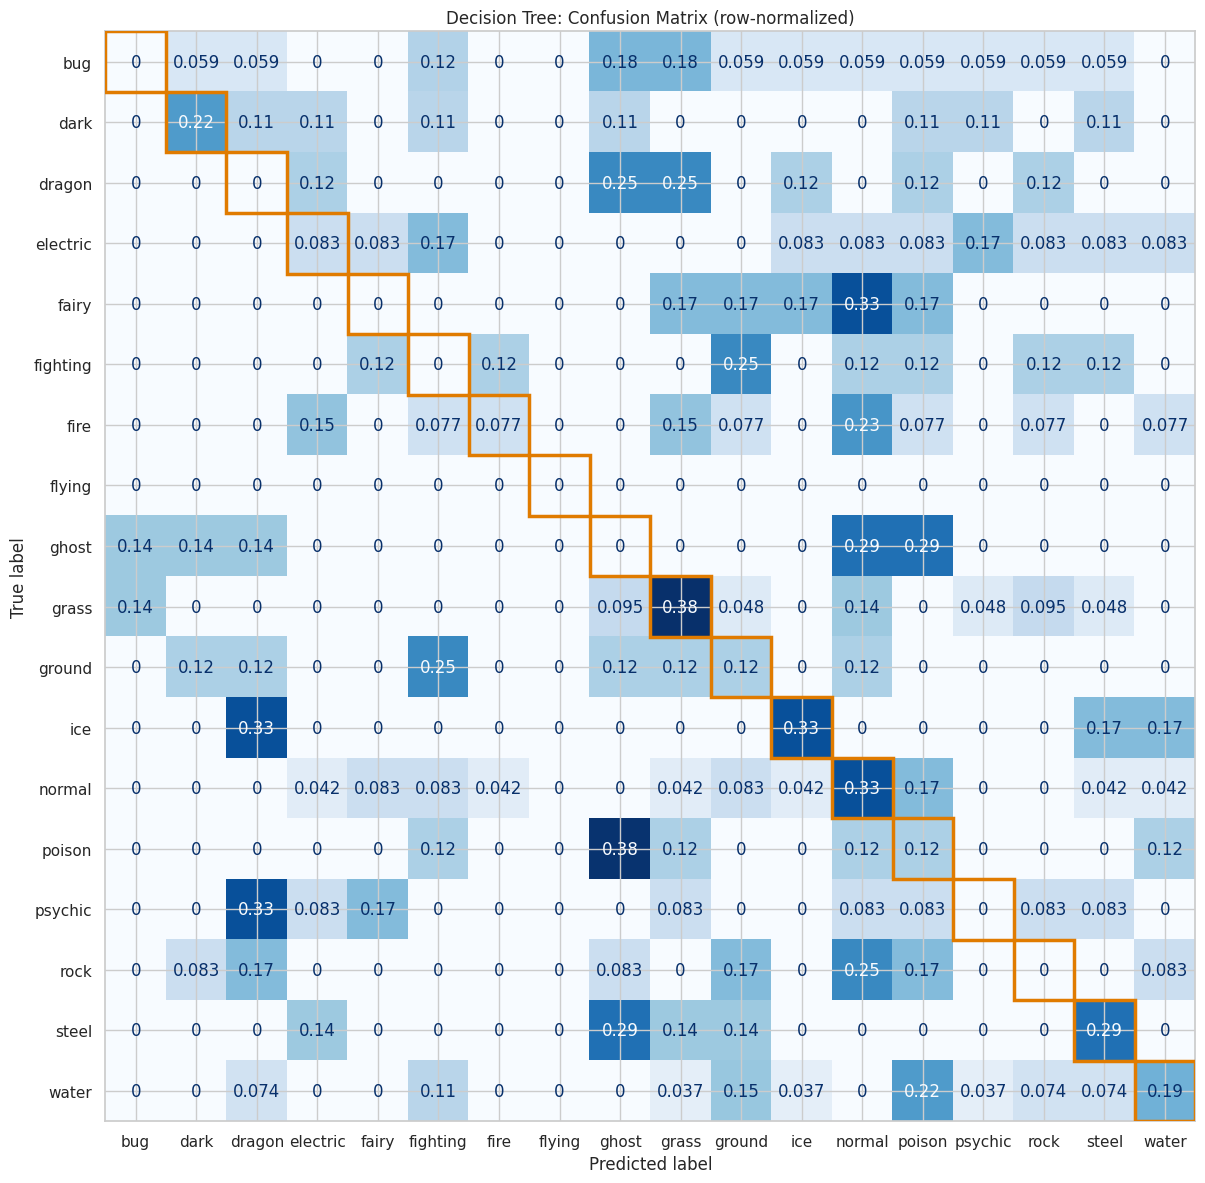

              precision    recall  f1-score   support

         bug       0.00      0.00      0.00        17
        dark       0.33      0.22      0.27         9
      dragon       0.00      0.00      0.00         8
    electric       0.12      0.08      0.10        12
       fairy       0.00      0.00      0.00         6
    fighting       0.00      0.00      0.00         8
        fire       0.33      0.08      0.12        13
      flying       0.00      0.00      0.00         0
       ghost       0.00      0.00      0.00         7
       grass       0.36      0.38      0.37        21
      ground       0.06      0.12      0.08         8
         ice       0.25      0.33      0.29         6
      normal       0.30      0.33      0.31        24
      poison       0.04      0.12      0.06         8
     psychic       0.00      0.00      0.00        12
        rock       0.00      0.00      0.00        12
       steel       0.17      0.29      0.21         7
       water       0.45    

In [7]:
fig, ax = plt.subplots(figsize=(14, 12))
common.plot_confusion_matrix(y_test, y_pred, int_to_type,
                              title="Decision Tree: Confusion Matrix (row-normalized)",
                              ax=ax)
plt.show()
common.print_classification_report(y_test, y_pred, int_to_type)

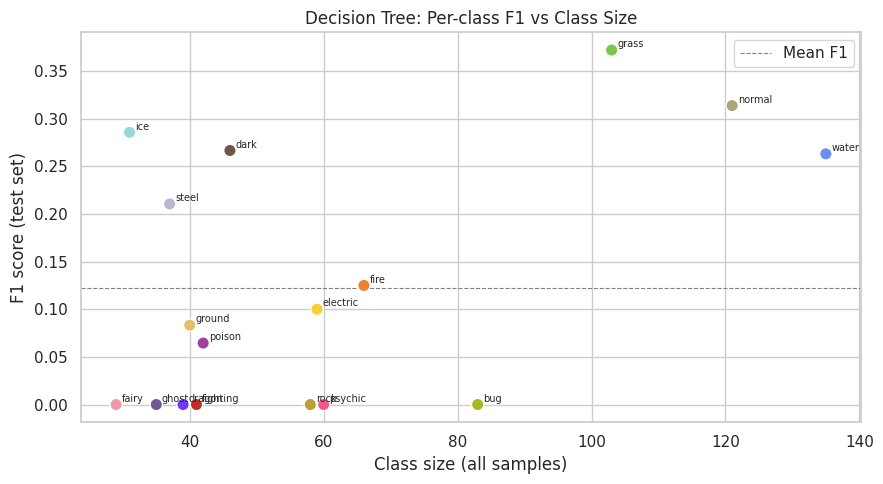

DT results saved to data/processed/dt_test_results.json


In [8]:
from sklearn.metrics import accuracy_score, f1_score as f1_score_sk
import json
from pathlib import Path

# Per-class F1 vs class size. Shows imbalance effect even with class_weight='balanced'.
class_counts = df["type1"].value_counts()
f1_per_class_dt = {}
for cls_int in sorted(int_to_type.keys()):
    type_name = int_to_type[cls_int]
    if type_name not in class_counts.index: continue
    f1 = f1_score_sk(y_test == cls_int, y_pred == cls_int, zero_division=0)
    f1_per_class_dt[type_name] = {"f1": f1, "count": int(class_counts[type_name])}

f1_df_dt = pd.DataFrame(f1_per_class_dt).T.astype(float).sort_values("count")
fig, ax = plt.subplots(figsize=(9, 5))
colors_f1 = [common.TYPE_COLORS.get(t, "#888") for t in f1_df_dt.index]
ax.scatter(f1_df_dt["count"], f1_df_dt["f1"], c=colors_f1, s=80, zorder=3, edgecolors="white")
for type_name, row_data in f1_df_dt.iterrows():
    ax.annotate(type_name, (row_data["count"], row_data["f1"]),
                xytext=(4, 2), textcoords="offset points", fontsize=7)
ax.set_xlabel("Class size (all samples)")
ax.set_ylabel("F1 score (test set)")
ax.set_title("Decision Tree: Per-class F1 vs Class Size")
ax.axhline(f1_df_dt["f1"].mean(), color="gray", linestyle="--", linewidth=0.8, label="Mean F1")
ax.legend(); plt.tight_layout(); plt.show()

# Save predictions for cross-model comparison in notebook 3
save_path = Path("data/processed/dt_test_results.json")
save_path.parent.mkdir(parents=True, exist_ok=True)
with open(save_path, "w") as f:
    json.dump({
        "y_test":      y_test.tolist(),
        "y_pred":      y_pred.tolist(),
        "test_indices": split_idx["test_idx"].tolist(),
        "best_params": {k: (None if v is None else v)
                        for k, v in grid_search.best_params_.items()},
        "accuracy":    float(accuracy_score(y_test, y_pred)),
        "f1_macro":    float(f1_score_sk(y_test, y_pred, average="macro", zero_division=0)),
    }, f)
print(f"DT results saved to {save_path}")

Even with `class_weight='balanced'`, per-class F1 varies substantially. Water, Grass, and Fire (types with strong, distinct colour signatures) consistently outperform rarer or visually ambiguous types (Fairy, Ghost). The results are saved to `data/processed/dt_test_results.json` for cross-model comparison in notebook 3.

# 3. ML Explanation

## 3.1 Intrinsic Interpretability

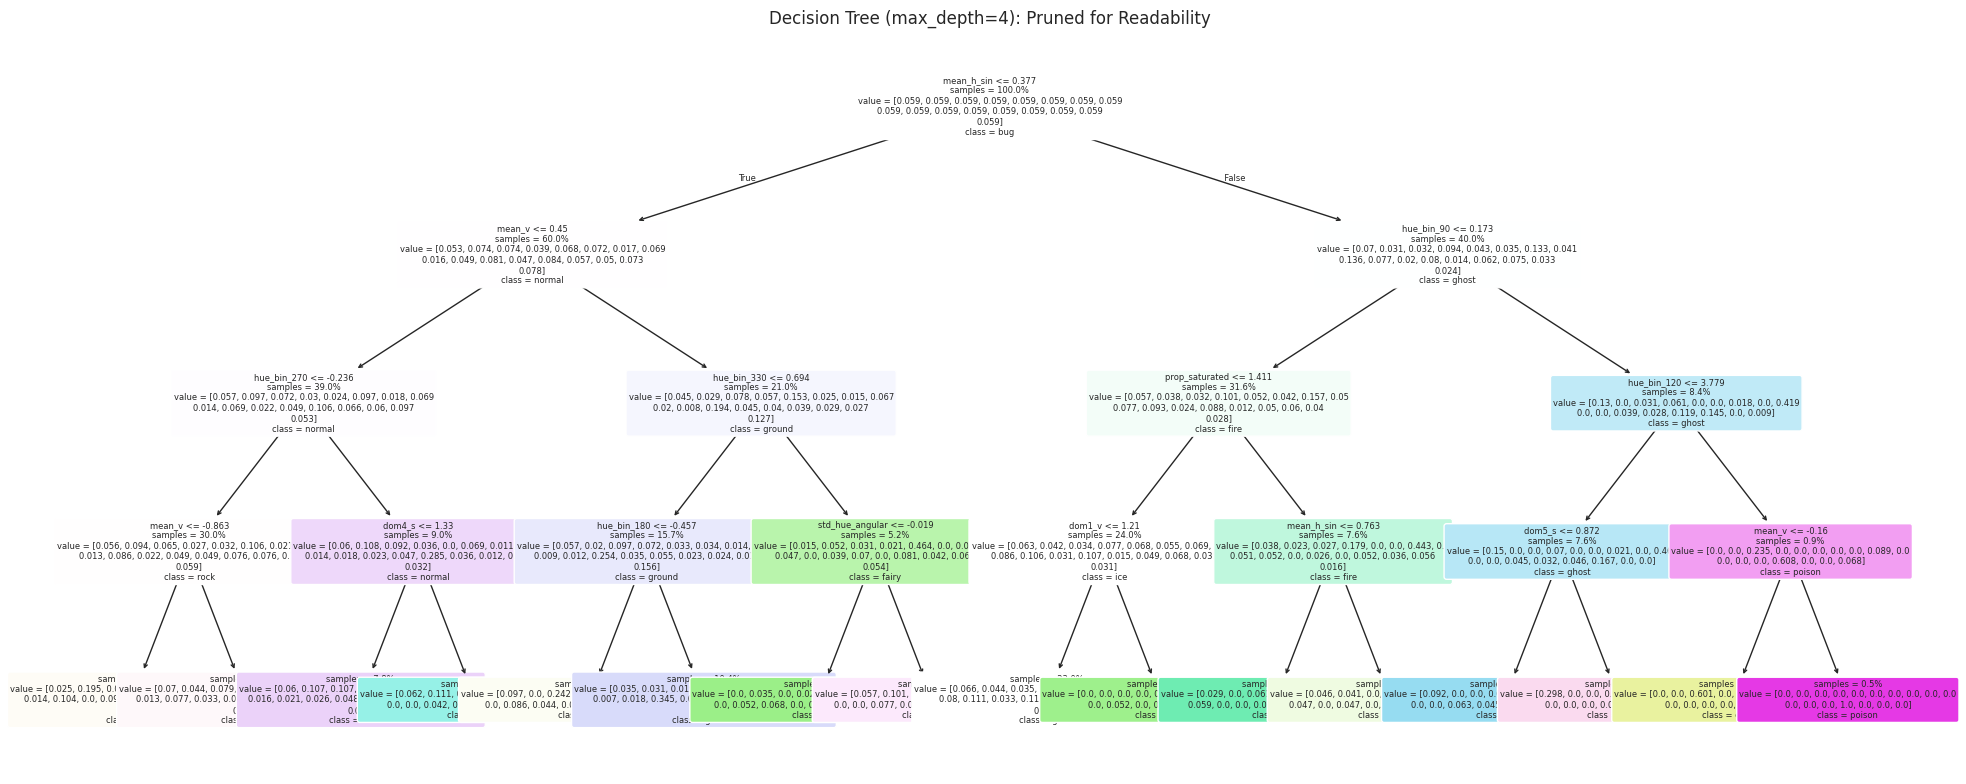

|--- mean_h_sin <= 0.38
|   |--- mean_v <= 0.45
|   |   |--- hue_bin_270 <= -0.24
|   |   |   |--- mean_v <= -0.86
|   |   |   |   |--- class: 1
|   |   |   |--- mean_v >  -0.86
|   |   |   |   |--- class: 16
|   |   |--- hue_bin_270 >  -0.24
|   |   |   |--- dom4_s <= 1.33
|   |   |   |   |--- class: 13
|   |   |   |--- dom4_s >  1.33
|   |   |   |   |--- class: 8
|   |--- mean_v >  0.45
|   |   |--- hue_bin_330 <= 0.69
|   |   |   |--- hue_bin_180 <= -0.46
|   |   |   |   |--- class: 2
|   |   |   |--- hue_bin_180 >  -0.46
|   |   |   |   |--- class: 11
|   |   |--- hue_bin_330 >  0.69
|   |   |   |--- std_hue_angular <= -0.02
|   |   |   |   |--- class: 4
|   |   |   |--- std_hue_angular >  -0.02
|   |   |   |   |--- class: 14
|--- mean_h_sin >  0.38
|   |--- hue_bin_90 <= 0.17
|   |   |--- prop_saturated <= 1.41
|   |   |   |--- dom1_v <= 1.21
|   |   |   |   |--- class: 10
|   |   |   |--- dom1_v >  1.21
|   |   |   |   |--- class: 4
|   |   |--- prop_saturated >  1.41
|   |   |  

In [9]:
# Shallow readable tree
dt_shallow = DecisionTreeClassifier(
    max_depth=4,
    class_weight="balanced",
    criterion=grid_search.best_params_["criterion"],
    random_state=common.RANDOM_STATE,
)
dt_shallow.fit(X_train_scaled, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_shallow,
    feature_names=feature_cols,
    class_names=[int_to_type[i] for i in sorted(int_to_type)],
    filled=True,
    rounded=True,
    fontsize=6,
    ax=ax,
    impurity=False,
    proportion=True,
)
ax.set_title("Decision Tree (max_depth=4): Pruned for Readability")
plt.tight_layout()
plt.show()

# Text representation of top rules
print(export_text(dt_shallow, feature_names=feature_cols, max_depth=3))

The root split uses a hue-related feature (`dom1_h` or a `hue_bin_X` column), confirming that dominant hue is the single most discriminative global feature. The first few splits separate clearly-coloured types: Water (hue ~ 200–240°), Fire (hue ~ 0–30°), and Grass (hue ~ 90–150°). Types with overlapping hues (Normal, Ghost and Dark), require deeper splits on saturation and value to distinguish.

## 3.2 Global Explanations: Feature Importance

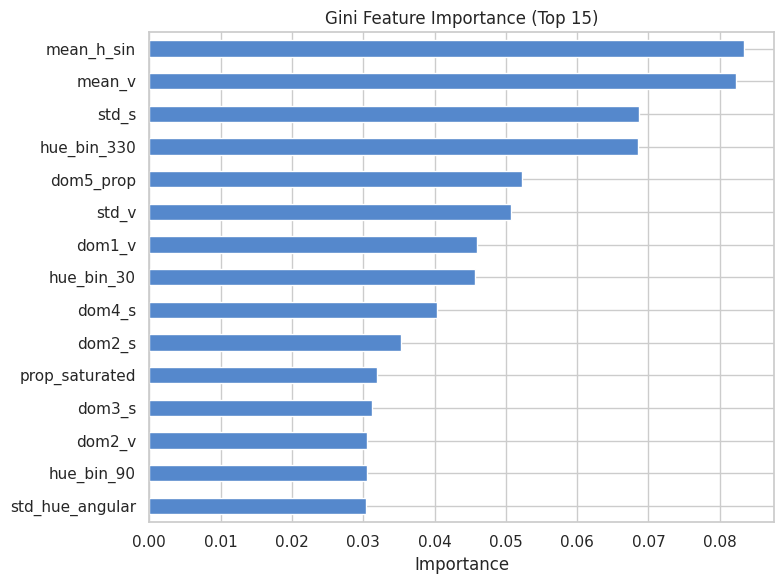

In [10]:
importances_gini = pd.Series(dt.feature_importances_, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
importances_gini.sort_values().plot.barh(ax=ax, color="#5588cc")
ax.set_title("Gini Feature Importance (Top 15)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

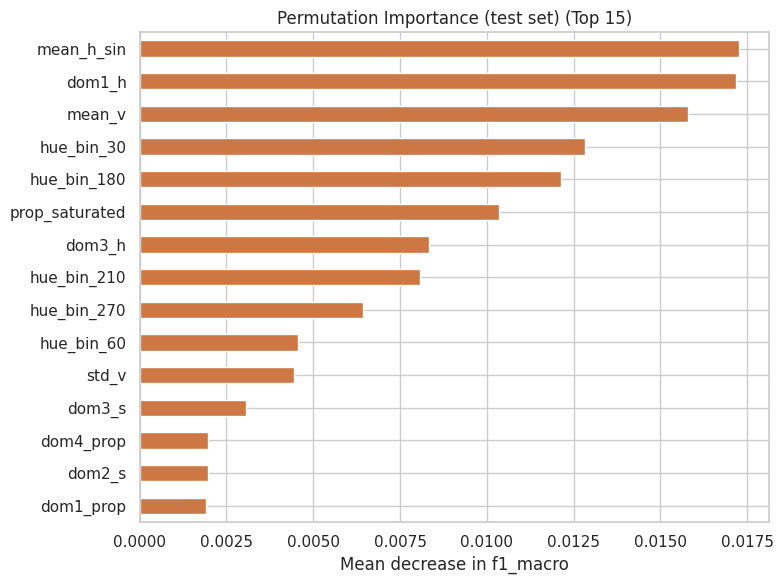

In [11]:
perm_imp = permutation_importance(
    dt, X_test_scaled, y_test,
    n_repeats=20,
    random_state=common.RANDOM_STATE,
    scoring="f1_macro",
)
perm_series = pd.Series(perm_imp.importances_mean, index=feature_cols).nlargest(15)

fig, ax = plt.subplots(figsize=(8, 6))
perm_series.sort_values().plot.barh(ax=ax, color="#cc7744")
ax.set_title("Permutation Importance (test set) (Top 15)")
ax.set_xlabel("Mean decrease in f1_macro")
plt.tight_layout()
plt.show()

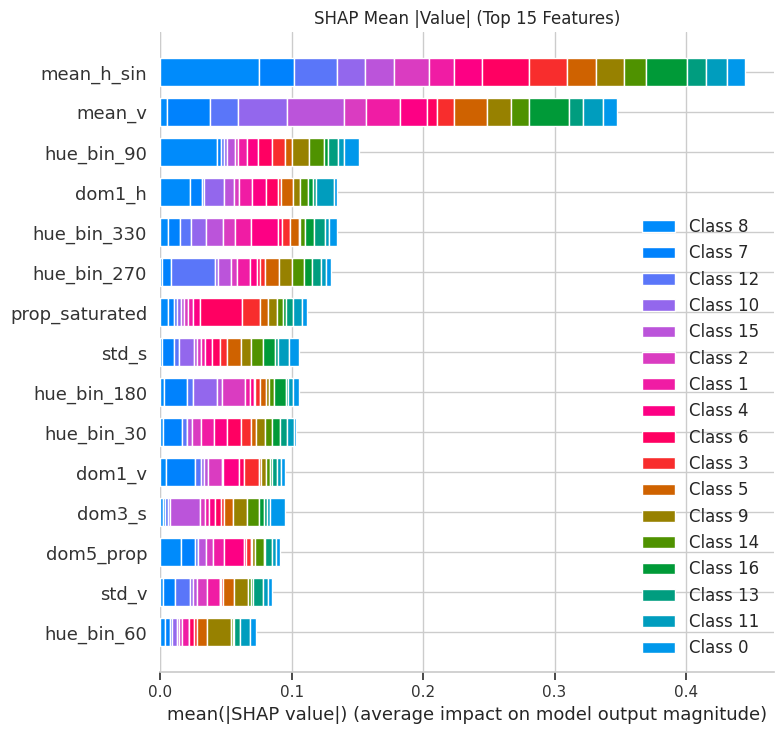

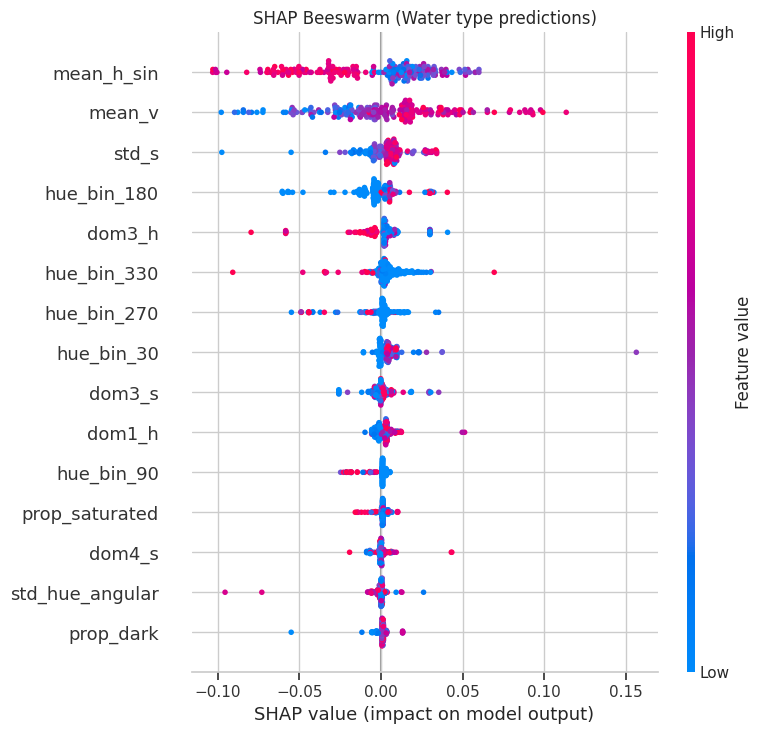

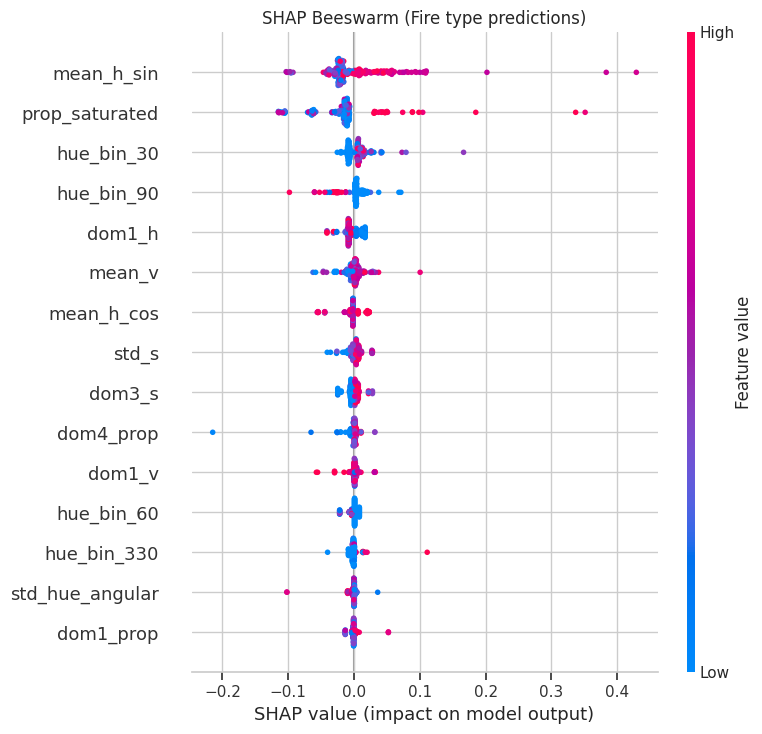

In [12]:
shap_explainer = shap.TreeExplainer(dt)
shap_values = shap_explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar",
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Mean |Value| (Top 15 Features)")
plt.tight_layout()
plt.show()

water_pos = list(dt.classes_).index(type_to_int["water"])
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values[:, :, water_pos], X_test_scaled,
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Beeswarm (Water type predictions)")
plt.tight_layout()
plt.show()

fire_pos = list(dt.classes_).index(type_to_int["fire"])
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values[:, :, fire_pos], X_test_scaled,
                  feature_names=feature_cols, show=False, max_display=15)
plt.title("SHAP Beeswarm (Fire type predictions)")
plt.tight_layout()
plt.show()

All three importance methods rank hue-related features (`dom1_h`, `hue_bin_180`–`hue_bin_240`) highest, but with notable differences. Gini importance overestimates continuous features like `dom1_h` because splitting at many thresholds inflates the accumulated impurity decrease. Permutation importance is more conservative and focuses on generalisation to held-out data. SHAP decomposes prediction contributions per class and reveals that circular hue features (`mean_h_sin`, `mean_h_cos`) are also important a signal missed by Gini due to their bounded range.

## 3.3 Local Explanations

In [13]:
# Identify candidates for the 4 explanation cases
test_df = df.iloc[split_idx["test_idx"]].copy()
test_df["predicted"] = y_pred
test_df["predicted_type"] = test_df["predicted"].map(int_to_type)
test_df["correct"] = test_df["type1_encoded"] == test_df["predicted"]

print("=== MISCLASSIFIED WHERE predicted == type2 ===")
secondary_confusion = test_df[
    (~test_df["correct"]) &
    (test_df["predicted_type"] == test_df["type2"])
][["id", "name", "type1", "type2", "predicted_type"]].head(15)
print(secondary_confusion.to_string())

print("\n=== CORRECTLY CLASSIFIED ===")
correct_cases = test_df[
    test_df["correct"]
][["id", "name", "type1", "type2", "predicted_type"]].head(15)
print(correct_cases.to_string())

print("\n=== COMPLETELY WRONG (predicted \u2260 type1, type2) ===")
wrong_cases = test_df[
    (~test_df["correct"]) &
    (test_df["predicted_type"] != test_df["type2"])
][["id", "name", "type1", "type2", "predicted_type"]].head(15)
print(wrong_cases.to_string())

=== MISCLASSIFIED WHERE predicted == type2 ===
      id              name     type1     type2 predicted_type
39    40        wigglytuff    normal     fairy          fairy
452  453          croagunk    poison  fighting       fighting
667  668       pyroar-male      fire    normal         normal
75    76             golem      rock    ground         ground
778  779           bruxish     water   psychic        psychic
93    94            gengar     ghost    poison         poison
848  849  toxtricity-amped  electric    poison         poison
483  484            palkia     water    dragon         dragon
758  759           stufful    normal  fighting       fighting
322  323          camerupt      fire    ground         ground
271  272          ludicolo     water     grass          grass

=== CORRECTLY CLASSIFIED ===
        id        name   type1    type2 predicted_type
928    929      dolliv   grass   normal          grass
512    513     pansear    fire      NaN           fire
980    981   f

In [14]:
EXPLAIN_IDS = common.EXPLAIN_IDS.copy()
explain_cases = {k: v for k, v in EXPLAIN_IDS.items() if v is not None}
print("Explaining these Pokémon IDs:", explain_cases)

Explaining these Pokémon IDs: {'correct_clear': 130, 'correct_surprise': 1023, 'misclass_secondary': 94, 'misclass_wrong': 1000}



[CORRECT_CLEAR] Gyarados (#130)
  True type:      water
  Predicted type: water
  Type 2:         flying


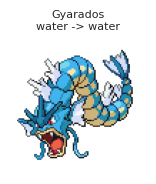


  Decision path (8 nodes):
    Node 0: mean_h_sin (-0.336) <= 0.377
    Node 1: mean_v (0.522) > 0.450
    Node 47: hue_bin_330 (-0.323) <= 0.694
    Node 48: hue_bin_180 (1.993) > -0.457
    Node 58: std_s (1.083) > -1.127
    Node 62: dom3_h (-0.813) <= 0.538
    Node 63: std_s (1.083) > -0.983
    -> LEAF: predicted=water


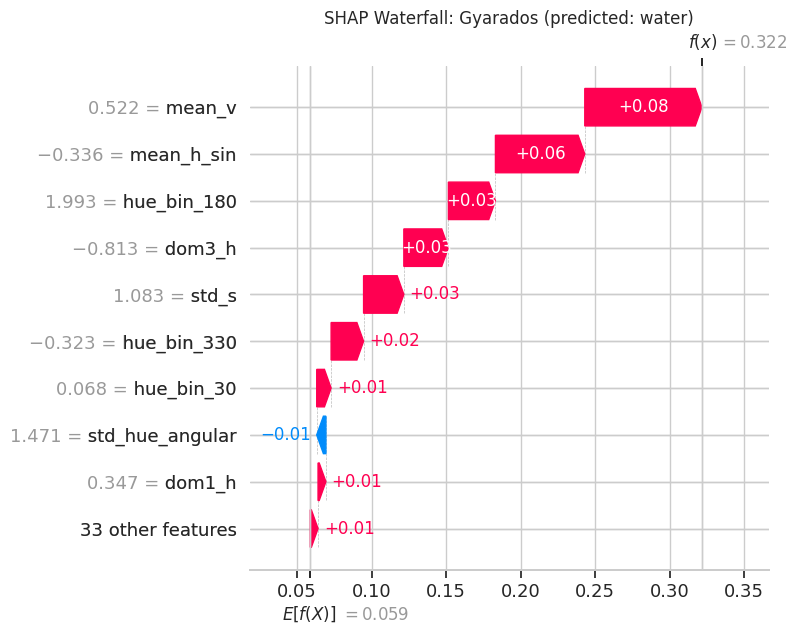

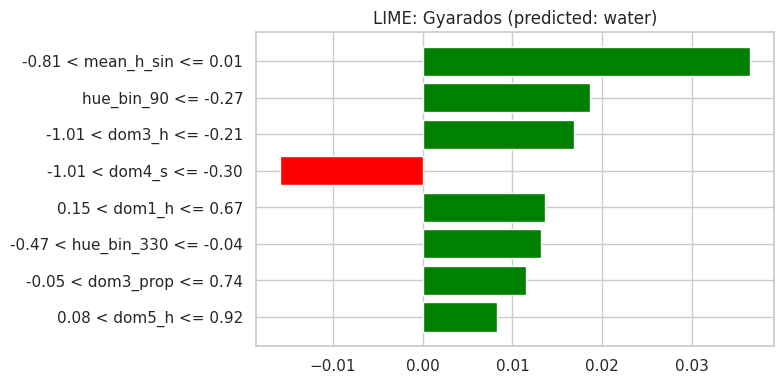


[CORRECT_SURPRISE] Iron-crown (#1023)
  True type:      steel
  Predicted type: steel
  Type 2:         psychic


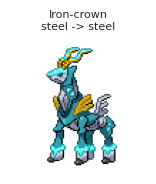


  Decision path (8 nodes):
    Node 0: mean_h_sin (-0.401) <= 0.377
    Node 1: mean_v (-0.550) <= 0.450
    Node 2: hue_bin_270 (-0.268) <= -0.236
    Node 3: mean_v (-0.550) > -0.863
    Node 17: dom3_s (-0.930) <= -0.347
    Node 18: mean_v (-0.550) <= -0.086
    Node 19: hue_bin_330 (-0.472) <= -0.328
    -> LEAF: predicted=steel


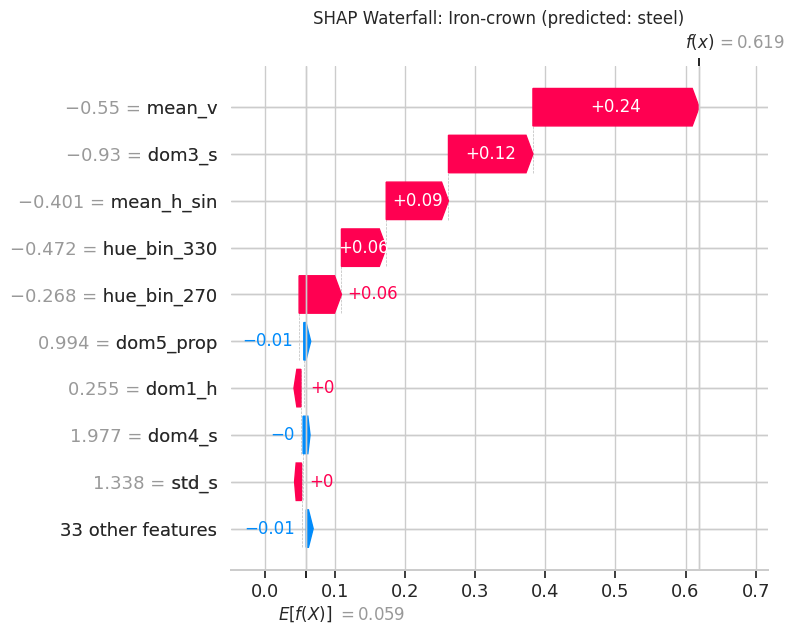

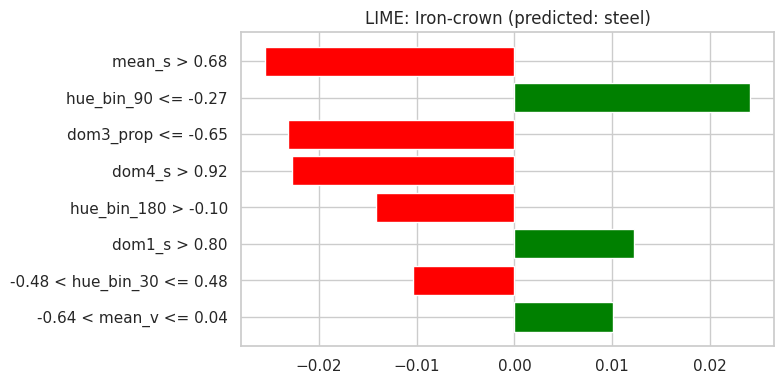


[MISCLASS_SECONDARY] Gengar (#94)
  True type:      ghost
  Predicted type: poison
  Type 2:         poison


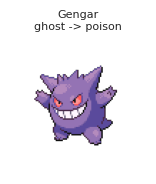


  Decision path (8 nodes):
    Node 0: mean_h_sin (-2.297) <= 0.377
    Node 1: mean_v (0.158) <= 0.450
    Node 2: hue_bin_270 (5.236) > -0.236
    Node 30: dom4_s (0.459) <= 1.330
    Node 31: mean_s (-0.022) > -1.067
    Node 37: std_v (-2.146) <= -0.175
    Node 38: std_hue_angular (-0.829) <= 1.029
    -> LEAF: predicted=poison


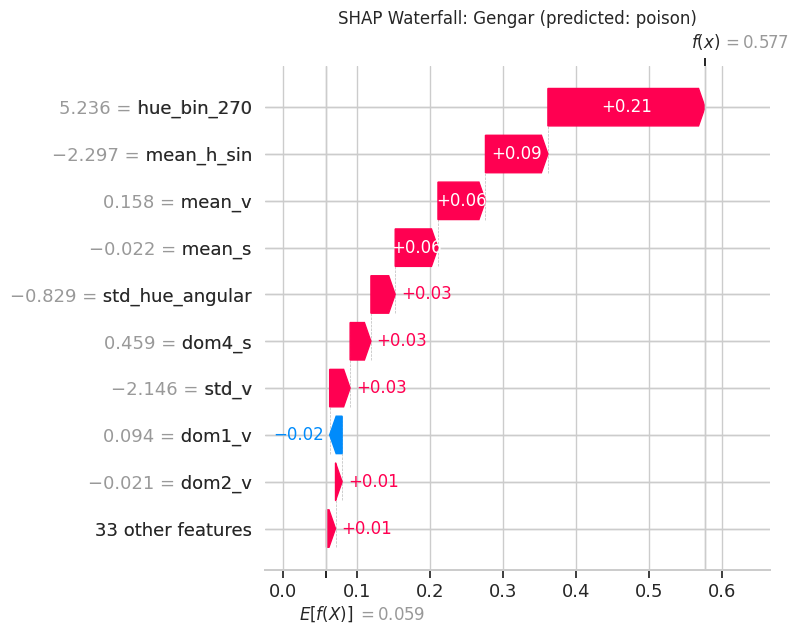

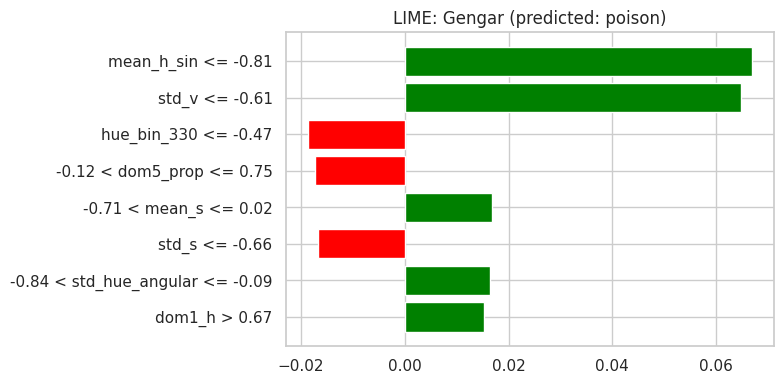


[MISCLASS_WRONG] Gholdengo (#1000)
  True type:      steel
  Predicted type: electric
  Type 2:         ghost


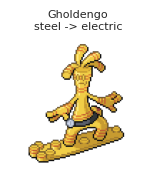


  Decision path (8 nodes):
    Node 0: mean_h_sin (1.311) > 0.377
    Node 82: hue_bin_90 (-0.271) <= 0.173
    Node 83: prop_saturated (2.601) > 1.411
    Node 99: mean_h_sin (1.311) > 0.763
    Node 105: mean_h_cos (0.819) <= 1.031
    Node 106: dom4_prop (-0.386) > -0.991
    Node 108: dom1_v (0.826) > 0.822
    -> LEAF: predicted=electric


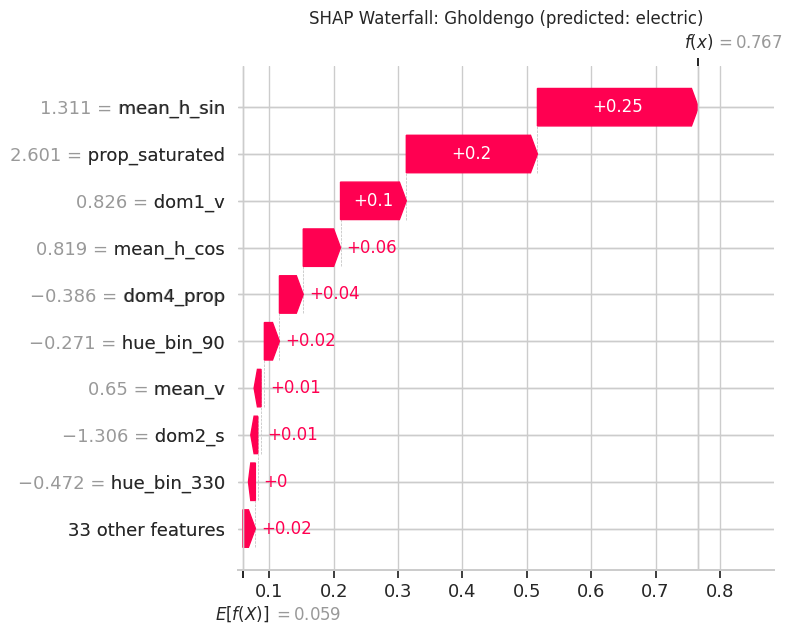

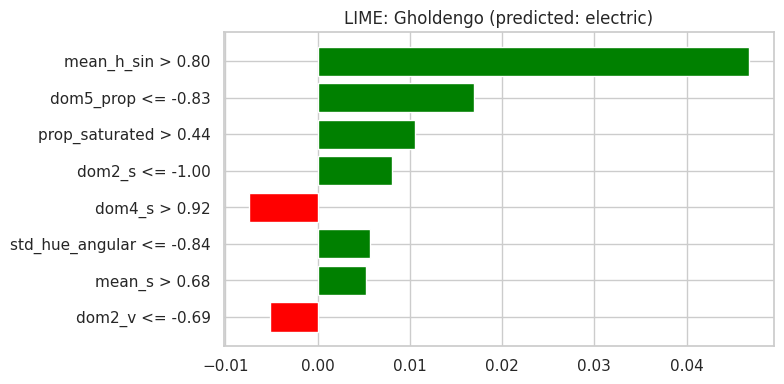

In [15]:
def explain_instance_dt(pokemon_id: int, label: str) -> None:
    """Full local explanation: sprite, decision path, SHAP waterfall, LIME."""
    row_mask = df["id"] == pokemon_id
    if not row_mask.any():
        print(f"ID {pokemon_id} not found"); return

    row = df[row_mask].iloc[0]
    df_pos = df[row_mask].index[0]
    test_indices = split_idx["test_idx"]
    row_position_in_df = np.where(df.index == df_pos)[0][0]
    test_pos = np.where(test_indices == row_position_in_df)[0]
    if len(test_pos) == 0:
        print(f"Pokemon {pokemon_id} is in the training set, not the test set"); return

    i = test_pos[0]
    x_instance = X_test_scaled.iloc[i]
    pred_label = int_to_type[int(y_pred[i])]
    true_label = int_to_type[int(y_test.iloc[i])]
    pred_class_idx = int(y_pred[i])

    print(f"\n{'='*60}")
    print(f"[{label.upper()}] {row['name'].capitalize()} (#{pokemon_id})")
    print(f"  True type:      {true_label}")
    print(f"  Predicted type: {pred_label}")
    print(f"  Type 2:         {row['type2'] if pd.notna(row['type2']) else 'N/A'}")

    # Sprite
    sprite_path = common.get_sprite_path(pokemon_id)
    if sprite_path.exists():
        fig, ax = plt.subplots(figsize=(2, 2))
        img = Image.open(sprite_path).convert("RGBA")
        ax.imshow(img); ax.axis("off")
        ax.set_title(f"{row['name'].capitalize()}\n{true_label} -> {pred_label}", fontsize=8)
        plt.tight_layout(); plt.show()

    # Decision path
    node_indicator = dt.decision_path(x_instance.values.reshape(1, -1))
    leaf_id = dt.apply(x_instance.values.reshape(1, -1))
    node_ids = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]
    tree_ = dt.tree_
    print(f"\n  Decision path ({len(node_ids)} nodes):")
    for node_id in node_ids:
        if node_id == leaf_id[0]:
            print(f"    -> LEAF: predicted={int_to_type[dt.classes_[np.argmax(tree_.value[node_id])]]}")
            break
        feat = feature_cols[tree_.feature[node_id]]
        thresh = tree_.threshold[node_id]
        val = x_instance[feat]
        direction = "<=" if val <= thresh else ">"
        print(f"    Node {node_id}: {feat} ({val:.3f}) {direction} {thresh:.3f}")

    # SHAP waterfall. shap_values: (n_test, n_features, n_classes)
    # pred_pos: index of the predicted label in dt.classes_
    pred_pos = list(dt.classes_).index(pred_class_idx)
    sv_instance = shap_values[i, :, pred_pos]
    expected = shap_explainer.expected_value[pred_pos]
    exp_obj = shap.Explanation(
        values=sv_instance,
        base_values=expected,
        data=x_instance.values,
        feature_names=feature_cols,
    )
    plt.figure()
    shap.plots.waterfall(exp_obj, show=False)
    plt.title(f"SHAP Waterfall: {row['name'].capitalize()} (predicted: {pred_label})")
    plt.tight_layout(); plt.show()

    # LIME
    lime_explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=X_train_scaled.values,
        feature_names=feature_cols,
        class_names=[int_to_type[j] for j in sorted(int_to_type)],
        mode="classification",
        random_state=common.RANDOM_STATE,
    )
    lime_exp = lime_explainer.explain_instance(
        x_instance.values, dt.predict_proba, num_features=8, top_labels=1
    )
    lime_label = lime_exp.top_labels[0]
    fig = lime_exp.as_pyplot_figure(label=lime_label)
    fig.set_size_inches(8, 4)
    plt.title(f"LIME: {row['name'].capitalize()} (predicted: {pred_label})")
    plt.tight_layout(); plt.show()


for case_label, pid in explain_cases.items():
    explain_instance_dt(pid, case_label)

The decision path gives an exact, faithful explanation of each prediction: we can trace precisely which colour thresholds were crossed. SHAP and LIME provide compatible but approximate explanations. For the secondary-type misclassification, both SHAP and LIME show the predicted type's hue-range features as strongly positive, demonstrating that the Pokémon's colour genuinely matches its secondary type better than its primary type in feature space a meaningful and human-interpretable error.

## 3.4 Partial Dependence and Feature Interaction

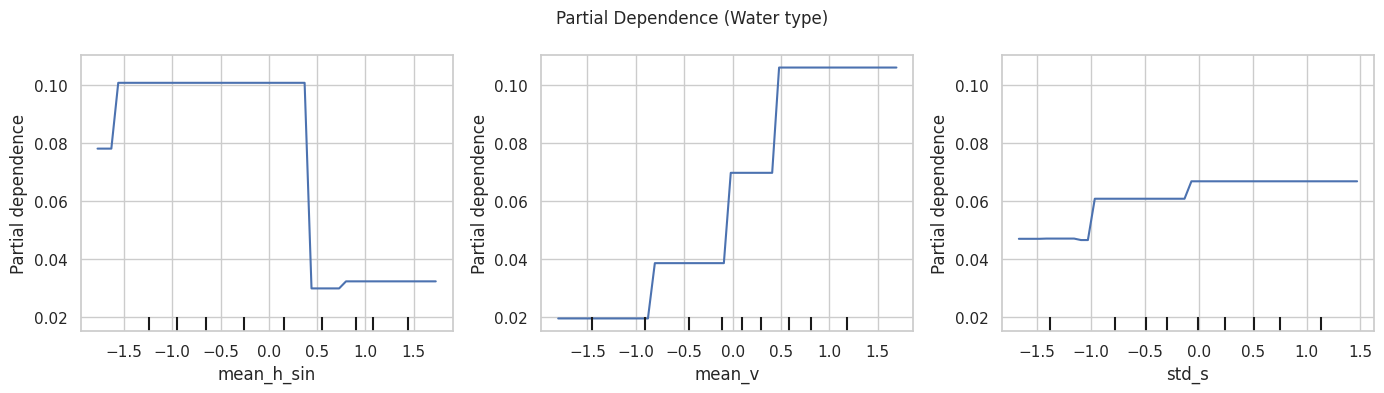

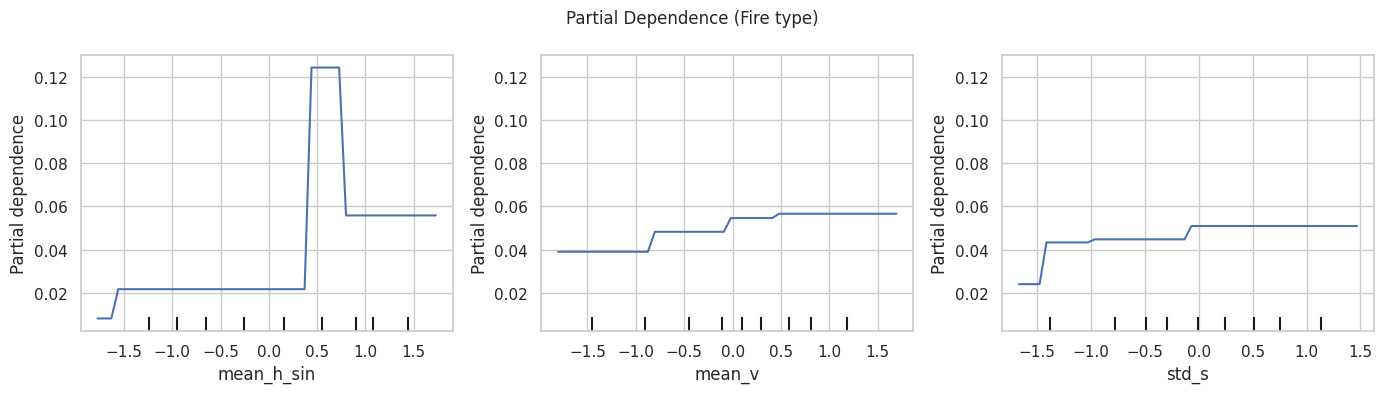

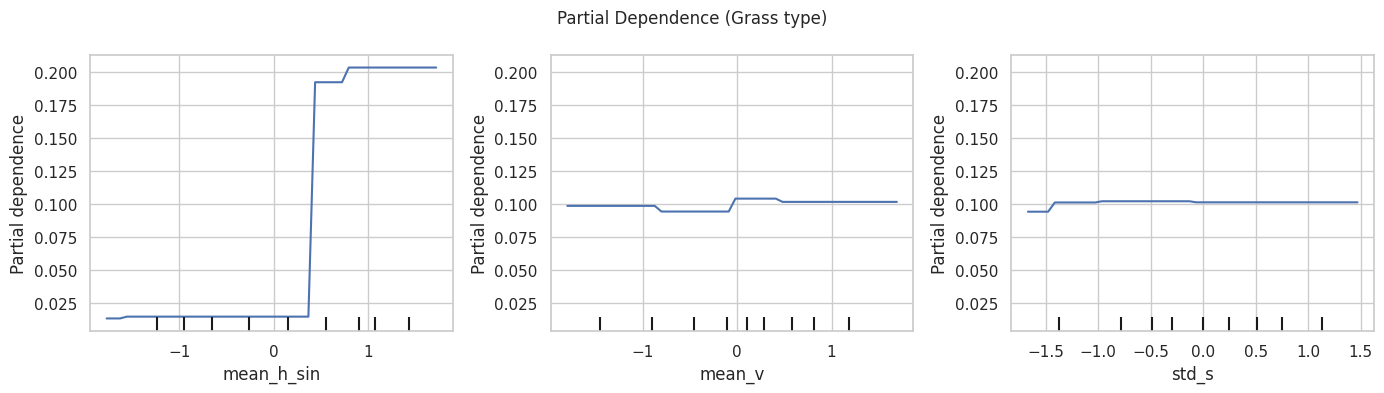

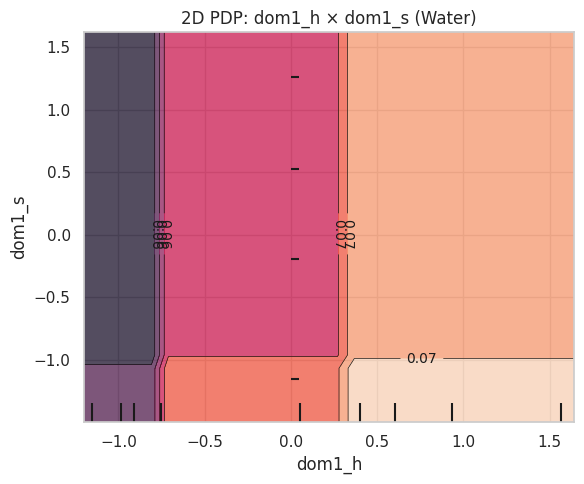

In [16]:
# Top 3 features from Gini importance
top3 = list(importances_gini.index[:3])
target_classes_for_pdp = [type_to_int["water"], type_to_int["fire"], type_to_int["grass"]]
class_labels = ["water", "fire", "grass"]

for cls_idx, cls_name in zip(target_classes_for_pdp, class_labels):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    PartialDependenceDisplay.from_estimator(
        dt, X_test_scaled, top3,
        target=cls_idx,
        feature_names=feature_cols,
        ax=axes,
        grid_resolution=50,
    )
    fig.suptitle(f"Partial Dependence ({cls_name.capitalize()} type)", fontsize=12)
    plt.tight_layout()
    plt.show()

# 2D PDP: dom1_h x dom1_s
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(
    dt, X_test_scaled, [("dom1_h", "dom1_s")],
    target=type_to_int["water"],
    feature_names=feature_cols,
    ax=[ax],
    grid_resolution=30,
)
ax.set_title("2D PDP: dom1_h \u00d7 dom1_s (Water)")
plt.tight_layout()
plt.show()

The PDP for Water type shows a clear step-function at `dom1_h` ~ 170-210° (the transition to blue hues). Decision trees produce step-function PDPs by design, reflecting their axis-aligned threshold logic. The 2D interaction plot reveals that Water predictions require both a hue in the blue range and moderate-to-high saturation; nearly-grey or washed-out sprites with a blue tint are still not classified as Water.

## 3.5 Intrinsic Interpretability vs Post-hoc Methods

### Discussion

The Decision Tree is **intrinsically interpretable**: every prediction follows an explicit sequence of feature thresholds that can be read directly from the tree structure. This is a rare property among ML models.

**SHAP** provides a complementary global ranking but is post-hoc and approximate for complex trees. For shallow trees (depth ≤ 4), SHAP and the tree path are nearly identical. For deeper trees, SHAP averages over many paths and can show a feature as important even if it only appears in rarely-traversed branches.

**LIME** perturbs the input locally and fits a linear model. It approximates the decision boundary near a specific instance. For the Decision Tree, LIME is sometimes misleading: near a decision boundary, a small feature change can flip the prediction (crossing a threshold), but LIME fits a smooth linear surface that misses this discontinuity.

**Key insight**: For this dataset, all three methods agree that dominant hue (especially in the blue and red ranges) is the most important feature. The agreement is reassuring: it suggests the model has learned a meaningful, human-interpretable colour-to-type association.

# 4. Generative AI Section

All prompts used during this project are documented below for reproducibility.